## Business Problem

- Which patients are at greatest risk of failing to complete behavioral health treatnment.
    

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("data/teds_discharge_data.csv")

df.head()

,DISYR,CASEID,STFIPS,EDUC,MARSTAT,SERVICES,DETCRIM,LOS,PSOURCE,NOPRIOR,...,BARBFLG,SEDHPFLG,INHFLG,OTCFLG,OTHERFLG,DIVISION,REGION,IDU,ALCDRUG,CBSA2020
0,2023,1459504,2,3,4,7,-9,33,1,0,...,0,0,0,0,0,9,4,0,1,-9
1,2023,1366386,2,5,3,7,2,35,7,0,...,0,0,0,0,0,9,4,0,1,-9
2,2023,1343932,2,3,2,7,-9,37,3,0,...,0,0,0,0,1,9,4,0,3,-9
3,2023,1307536,2,4,4,7,-9,36,1,1,...,0,0,0,0,0,9,4,0,1,-9
4,2023,1381539,2,4,4,7,-9,31,1,1,...,0,0,0,0,0,9,4,0,3,-9


In [3]:
df.columns.to_list()

['DISYR',
 'CASEID',
 'STFIPS',
 'EDUC',
 'MARSTAT',
 'SERVICES',
 'DETCRIM',
 'LOS',
 'PSOURCE',
 'NOPRIOR',
 'ARRESTS',
 'EMPLOY',
 'METHUSE',
 'PSYPROB',
 'PREG',
 'SEX',
 'VET',
 'LIVARAG',
 'DAYWAIT',
 'SERVICES_D',
 'REASON',
 'EMPLOY_D',
 'LIVARAG_D',
 'ARRESTS_D',
 'DSMCRIT',
 'AGE',
 'RACE',
 'ETHNIC',
 'DETNLF',
 'DETNLF_D',
 'PRIMINC',
 'SUB1',
 'SUB2',
 'SUB3',
 'SUB1_D',
 'SUB2_D',
 'SUB3_D',
 'ROUTE1',
 'ROUTE2',
 'ROUTE3',
 'FREQ1',
 'FREQ2',
 'FREQ3',
 'FREQ1_D',
 'FREQ2_D',
 'FREQ3_D',
 'FRSTUSE1',
 'FRSTUSE2',
 'FRSTUSE3',
 'HLTHINS',
 'PRIMPAY',
 'FREQ_ATND_SELF_HELP',
 'FREQ_ATND_SELF_HELP_D',
 'ALCFLG',
 'COKEFLG',
 'MARFLG',
 'HERFLG',
 'METHFLG',
 'OPSYNFLG',
 'PCPFLG',
 'HALLFLG',
 'MTHAMFLG',
 'AMPHFLG',
 'STIMFLG',
 'BENZFLG',
 'TRNQFLG',
 'BARBFLG',
 'SEDHPFLG',
 'INHFLG',
 'OTCFLG',
 'OTHERFLG',
 'DIVISION',
 'REGION',
 'IDU',
 'ALCDRUG',
 'CBSA2020']

In [4]:
df.shape

(1474025, 76)

In [5]:
df['REASON'].value_counts(dropna=False)

REASON
1    627897
4    370294
2    324461
7     70972
3     60662
5     16009
6      3730
Name: count, dtype: int64

In [6]:
df['TreatmentCompleted'] = (
    df['REASON'] == 1
).astype(int)

In [7]:
df['TreatmentCompleted'].value_counts(normalize=True)

TreatmentCompleted
0    0.574026
1    0.425974
Name: proportion, dtype: float64

In [8]:
leakage_cols = [
    'CASEID',
    'REASON',
    'LOS',
    'SERVICES_D',
    'EMPLOY_D',
    'LIVARAG_D',
    'ARRESTS_D',
    'DETNLF_D',
    'SUB1_D',
    'SUB2_D',
    'SUB3_D',
    'FREQ1_D',
    'FREQ2_D',
    'FREQ3_D',
    'FREQ_ATND_SELF_HELP_D'
]

In [9]:
df = df.drop(columns=leakage_cols)

In [10]:
print(df.shape)

(1474025, 62)


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1474025 entries, 0 to 1474024
Data columns (total 62 columns):
 #   Column               Non-Null Count    Dtype
---  ------               --------------    -----
 0   DISYR                1474025 non-null  int64
 1   STFIPS               1474025 non-null  int64
 2   EDUC                 1474025 non-null  int64
 3   MARSTAT              1474025 non-null  int64
 4   SERVICES             1474025 non-null  int64
 5   DETCRIM              1474025 non-null  int64
 6   PSOURCE              1474025 non-null  int64
 7   NOPRIOR              1474025 non-null  int64
 8   ARRESTS              1474025 non-null  int64
 9   EMPLOY               1474025 non-null  int64
 10  METHUSE              1474025 non-null  int64
 11  PSYPROB              1474025 non-null  int64
 12  PREG                 1474025 non-null  int64
 13  SEX                  1474025 non-null  int64
 14  VET                  1474025 non-null  int64
 15  LIVARAG              1474025 non

In [12]:
df['TreatmentCompleted'].value_counts()

TreatmentCompleted
0    846128
1    627897
Name: count, dtype: int64

In [13]:
pd.crosstab(df["PSYPROB"], df["TreatmentCompleted"], normalize="index")

TreatmentCompleted,0,1
PSYPROB,,
-9,0.480738,0.519262
1,0.661600,0.338400
2,0.514939,0.485061


## Project Finding #1 

- A Chi-Square test identified a statistically significant relationship between co-occurring mental health disorders and treatment completion outcomes (χ² = 35,938.41, p < 0.001). Patients with co-occurring mental health and substance use disorders completed treatment at substantially lower rates (33.8%) than patients without co-occurring disorders (48.5%), suggesting that clinical complexity is strongly associated with treatment retention risk.

In [14]:
pd.crosstab(df["EMPLOY"], df["TreatmentCompleted"], normalize="index")

TreatmentCompleted,0,1
EMPLOY,,
-9,0.197357,0.802643
1,0.550325,0.449675
2,0.648625,0.351375
3,0.706967,0.293033
4,0.548425,0.451575


## Project Finding #2: Employment Status and Treatment Completion

 A substantial relationship was observed between employment status and treatment completion outcomes. Individuals employed full-time completed treatment at a rate of 45.0%, while unemployed individuals completed treatment at a rate of only 29.3%.

The findings suggest that socioeconomic stability may play a significant role in treatment retention and successful program completion. Employment may provide structure, financial stability, transportation access, and social support that facilitate continued engagement in treatment services.

Conversely, unemployed individuals may face barriers such as housing instability, financial stress, transportation challenges, and competing life priorities that increase the likelihood of treatment discontinuation.

These results indicate that employment status should be considered an important risk factor when identifying patients at risk of failing to complete treatment programs.


In [15]:
pd.crosstab(df["SEX"], df["TreatmentCompleted"], normalize="index")

TreatmentCompleted,0,1
SEX,,
-9,0.583058,0.416942
1,0.568048,0.431952
2,0.585402,0.414598


## Project Finding #4: Sex and Treatment Completion

Analysis of treatment completion outcomes by sex revealed only modest differences between male and female patients. Male patients completed treatment at a rate of 43.2%, while female patients completed treatment at a rate of 41.5%.

Although the difference was statistically significant due to the large sample size, the practical effect size was relatively small compared to other factors examined in the study, such as employment status, co-occurring mental health disorders, and health insurance coverage.

These findings suggest that demographic characteristics alone may be less predictive of treatment completion than socioeconomic, clinical, and healthcare access factors. As a result, intervention strategies may be more effective when focused on patient engagement barriers, treatment complexity, and access to care rather than sex-based targeting.


In [16]:
pd.crosstab(df["HLTHINS"], df["TreatmentCompleted"], normalize="index")

TreatmentCompleted,0,1
HLTHINS,,
-9,0.696737,0.303263
1,0.484836,0.515164
2,0.435624,0.564376
3,0.493447,0.506553
4,0.552994,0.447006


## Project Finding #3: Health Insurance Coverage and Treatment Completion

Analysis of health insurance coverage revealed meaningful differences in treatment completion outcomes. Patients covered by Medicaid completed treatment at the highest rate (56.4%), while uninsured patients completed treatment at the lowest rate (44.7%).

The findings suggest that access to healthcare coverage may play an important role in treatment retention and successful program completion. Insurance coverage may reduce financial barriers to care, improve continuity of services, and increase access to support resources throughout treatment.

Uninsured individuals may face additional challenges including treatment affordability concerns, transportation barriers, housing instability, and reduced access to ongoing healthcare services. These factors may contribute to lower treatment completion rates and increased risk of treatment discontinuation.

These results indicate that insurance status should be considered when identifying patients who may benefit from additional engagement and retention interventions.


In [21]:
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing.head(20)

DISYR                  0
MTHAMFLG               0
FRSTUSE2               0
FRSTUSE3               0
HLTHINS                0
PRIMPAY                0
FREQ_ATND_SELF_HELP    0
ALCFLG                 0
COKEFLG                0
MARFLG                 0
HERFLG                 0
METHFLG                0
OPSYNFLG               0
PCPFLG                 0
HALLFLG                0
AMPHFLG                0
STFIPS                 0
STIMFLG                0
BENZFLG                0
TRNQFLG                0
dtype: int64

In [22]:
from scipy.stats import chi2_contingency

table = pd.crosstab(
    df["PSYPROB"],
    df["TreatmentCompleted"]
)

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-Square:", chi2)
print("P-value:", p)

Chi-Square: 35938.40574160525
P-value: 0.0


In [23]:
df["DAYWAIT"].describe()

count    1.474025e+06
mean    -5.073867e+00
std      4.713515e+00
min     -9.000000e+00
25%     -9.000000e+00
50%     -9.000000e+00
75%      0.000000e+00
max      4.000000e+00
Name: DAYWAIT, dtype: float64

In [24]:
pd.qcut(
    df["DAYWAIT"],
    q=5,
    duplicates="drop"
).value_counts()

DAYWAIT
(-9.001, 0.0]    1299065
(0.0, 4.0]        174960
Name: count, dtype: int64

In [25]:
pd.crosstab(
    df["DAYWAIT"],
    df["TreatmentCompleted"],
    normalize="index"
)

TreatmentCompleted,0,1
DAYWAIT,,
-9,0.557351,0.442649
0,0.575974,0.424026
1,0.645767,0.354233
2,0.666362,0.333638
3,0.648546,0.351454
4,0.668176,0.331824


## Project Finding #5: Treatment Access Delays

Analysis of treatment admission wait times revealed a meaningful relationship between treatment access delays and treatment completion outcomes. Patients admitted to treatment on the same day completed treatment at a rate of 42.4%, while patients waiting more than 31 days completed treatment at a rate of only 33.2%.

A consistent decline in treatment completion rates was observed as admission delays increased. Patients entering treatment within one week of referral completed treatment at a rate of 35.4%, while those waiting 8–14 days completed treatment at a rate of 33.4%.

These findings suggest that rapid access to treatment services may improve patient engagement and retention. Delays between referral and treatment initiation may increase the likelihood of disengagement before treatment goals are achieved.

Healthcare organizations may improve treatment completion outcomes by reducing treatment entry delays, expanding rapid-access treatment programs, and prioritizing timely admission for high-risk patients.


In [26]:
pd.crosstab(
    df["LIVARAG"],
    df["TreatmentCompleted"],
    normalize="index"
)

TreatmentCompleted,0,1
LIVARAG,,
-9,0.142734,0.857266
1,0.621703,0.378297
2,0.653767,0.346233
3,0.671077,0.328923


## Project Finding #6: Living Arrangement and Treatment Completion

Analysis of living arrangements revealed meaningful differences in treatment completion outcomes. Patients experiencing homelessness completed treatment at a rate of 37.8%, compared to 34.6% for patients in dependent living situations and 32.9% for patients living independently.

Although these findings may appear counterintuitive, they suggest that housing status alone does not fully explain treatment retention outcomes. Individuals experiencing homelessness may receive additional support services, case management resources, structured treatment programs, or referral pathways that improve retention and engagement.

The results highlight the importance of examining social determinants of health within the broader context of treatment delivery and support systems. Further investigation is warranted to determine whether treatment intensity, referral source, or program type contributes to the observed differences.


# Feature Engineering and Predictive Modeling

In [27]:
# Target
y = df["TreatmentCompleted"]

# Features
X = df.drop(columns=["TreatmentCompleted"])

In [28]:
print(X.shape)
print(y.shape)

(1474025, 61)
(1474025,)


In [29]:
X.dtypes.value_counts()

int64    61
Name: count, dtype: int64

In [30]:
for col in X.columns:
    if (-9 in X[col].unique()):
        print(col)

EDUC
MARSTAT
DETCRIM
PSOURCE
NOPRIOR
ARRESTS
EMPLOY
METHUSE
PSYPROB
PREG
SEX
VET
LIVARAG
DAYWAIT
DSMCRIT
RACE
ETHNIC
DETNLF
PRIMINC
SUB1
SUB2
SUB3
ROUTE1
ROUTE2
ROUTE3
FREQ1
FREQ2
FREQ3
FRSTUSE1
FRSTUSE2
FRSTUSE3
HLTHINS
PRIMPAY
FREQ_ATND_SELF_HELP
IDU
CBSA2020


Step 1: Convert -9 to Missing

In [33]:
X_clean = X.replace(-9, np.nan)

In [34]:
missing_pct = (
    X_clean.isnull().mean() * 100
).sort_values(ascending=False)

missing_pct.head(20)

DETCRIM                86.039450
FRSTUSE3               82.162379
ROUTE3                 81.855125
FREQ3                  81.811163
DETNLF                 76.515324
PREG                   67.414053
DAYWAIT                58.629399
PRIMPAY                56.503248
FRSTUSE2               53.697597
FREQ2                  52.729703
ROUTE2                 52.655959
HLTHINS                46.076288
PRIMINC                38.460406
CBSA2020               33.458049
MARSTAT                23.587999
FREQ_ATND_SELF_HELP    20.797816
DSMCRIT                18.618952
EDUC                   17.350927
LIVARAG                16.426858
FRSTUSE1               15.451230
dtype: float64

Drop Extremely High Missing Variables (>75%)

In [35]:
drop_high_missing = [
    'DETCRIM',     # 86%
    'FRSTUSE3',    # 82%
    'ROUTE3',      # 82%
    'FREQ3',       # 82%
    'DETNLF'       # 77%
]

In [36]:
indicator_cols = [
    'PREG',
    'DAYWAIT',
    'PRIMPAY',
    'FRSTUSE2',
    'FREQ2',
    'ROUTE2',
    'HLTHINS',
    'PRIMINC',
    'CBSA2020',
    'MARSTAT',
    'FREQ_ATND_SELF_HELP',
    'DSMCRIT',
    'EDUC',
    'LIVARAG',
    'FRSTUSE1'
]

In [37]:
for col in indicator_cols:
    X[col + "_Missing"] = (X[col] == -9).astype(int)

In [38]:
X = X.drop(columns=drop_high_missing)

In [39]:
for col in indicator_cols:
    X[col + "_Missing"] = (X[col] == -9).astype(int)

In [40]:
X = X.replace(-9, np.nan)

In [41]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='most_frequent')

X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

Variables with more than 75% missing values were removed to reduce noise and improve model stability. For variables with moderate missingness, missing-value indicator features were engineered to preserve potentially informative missingness patterns. Remaining missing values were imputed using the most frequent category.

## Build the Baseline Logistic Regression

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_imputed,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [43]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

log_model.fit(X_train, y_train)

c:\Users\austi\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [44]:
from sklearn.metrics import (
    classification_report,
    roc_auc_score
)

preds = log_model.predict(X_test)
probs = log_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, preds))
print("ROC-AUC:", roc_auc_score(y_test, probs))

              precision    recall  f1-score   support

           0       0.77      0.75      0.76    169226
           1       0.67      0.69      0.68    125579

    accuracy                           0.72    294805
   macro avg       0.72      0.72      0.72    294805
weighted avg       0.73      0.72      0.72    294805

ROC-AUC: 0.8036602563952244


Next Model : Random Forest Model


In [45]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)
rf_probs = rf.predict_proba(X_test)[:,1]

print(classification_report(y_test, rf_preds))
print("ROC-AUC:", roc_auc_score(y_test, rf_probs))

              precision    recall  f1-score   support

           0       0.78      0.89      0.83    169226
           1       0.82      0.66      0.73    125579

    accuracy                           0.79    294805
   macro avg       0.80      0.78      0.78    294805
weighted avg       0.80      0.79      0.79    294805

ROC-AUC: 0.8825631602372146


Next Model : XGBoost Model


In [46]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, xgb_preds))
print("ROC-AUC:", roc_auc_score(y_test, xgb_probs))

              precision    recall  f1-score   support

           0       0.80      0.87      0.83    169226
           1       0.80      0.70      0.75    125579

    accuracy                           0.80    294805
   macro avg       0.80      0.78      0.79    294805
weighted avg       0.80      0.80      0.79    294805

ROC-AUC: 0.8836804087648819


# Model Explainability and Performance Visualization

To improve model interpretability and communicate results to stakeholders, feature importance analysis, confusion matrix evaluation, and ROC curve analysis were performed on the final Random Forest model.

These visualizations provide insight into model performance and the factors most strongly associated with treatment completion outcomes.

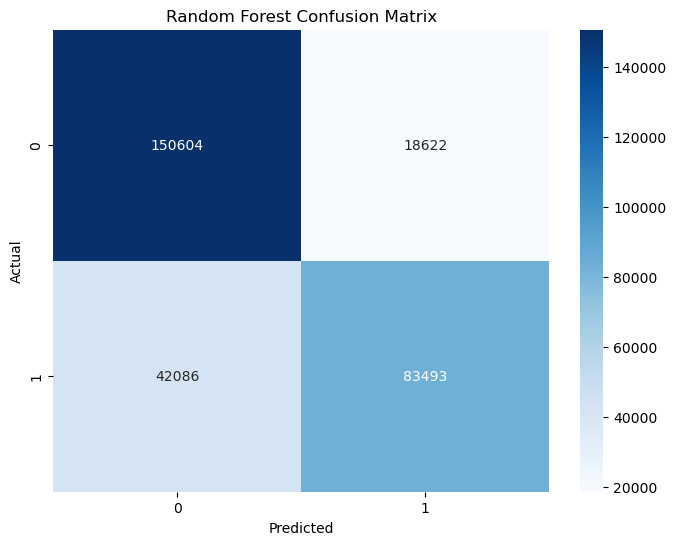

In [54]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_preds)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

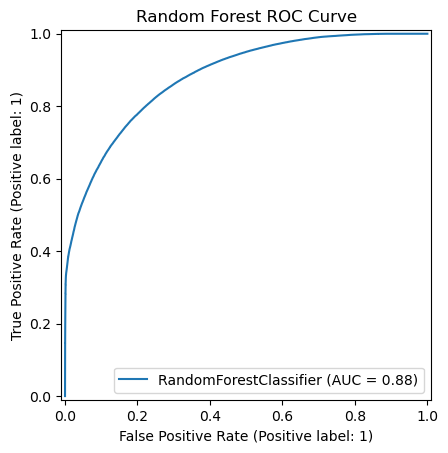

In [55]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_estimator(
    rf,
    X_test,
    y_test
)

plt.title("Random Forest ROC Curve")
plt.show()

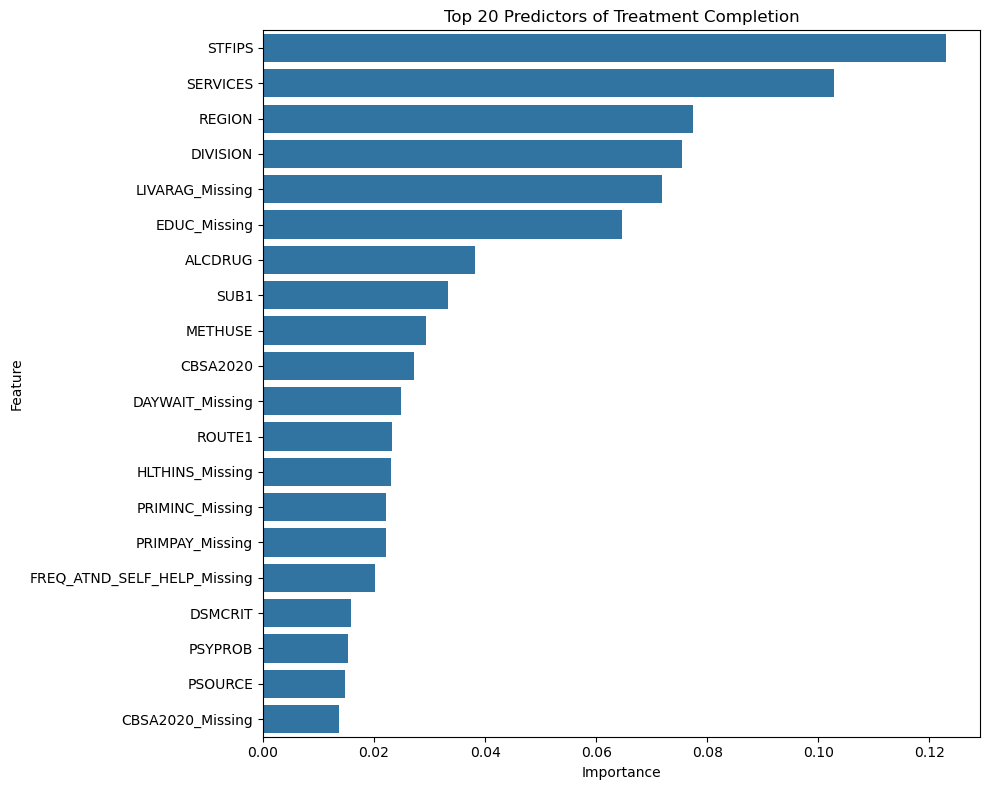

,Feature,Importance
1,STFIPS,0.122962
4,SERVICES,0.102753
52,REGION,0.077452
51,DIVISION,0.075431
69,LIVARAG_Missing,0.071932
68,EDUC_Missing,0.064679
54,ALCDRUG,0.038211
21,SUB1,0.033298
9,METHUSE,0.029268
55,CBSA2020,0.027182


In [56]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

top20 = feature_importance.head(20)

plt.figure(figsize=(10,8))

sns.barplot(
    data=top20,
    x='Importance',
    y='Feature'
)

plt.title("Top 20 Predictors of Treatment Completion")

plt.tight_layout()
plt.show()

feature_importance.head(20)

## Finding Section

## Model Performance Comparison

Three machine learning models were evaluated for predicting behavioral health treatment completion.

| Model               | ROC-AUC |
| ------------------- | ------- |
| Logistic Regression | 0.804   |
| Random Forest       | 0.883   |
| XGBoost             | 0.884   |

Tree-based models substantially outperformed Logistic Regression, indicating the presence of complex nonlinear relationships among demographic, clinical, socioeconomic, and treatment-access variables.

Although XGBoost achieved the highest ROC-AUC (0.884), the performance improvement over Random Forest (0.883) was negligible. Given its comparable performance and greater interpretability, Random Forest was selected as the preferred model for business recommendations and feature importance analysis.

The final model demonstrated strong discrimination between patients who completed treatment and those who did not, suggesting that behavioral health treatment completion can be predicted with a high degree of accuracy using information available at treatment admission.


In [47]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values(
    'Importance',
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
1,STFIPS,0.122962
4,SERVICES,0.102753
52,REGION,0.077452
51,DIVISION,0.075431
69,LIVARAG_Missing,0.071932
68,EDUC_Missing,0.064679
54,ALCDRUG,0.038211
21,SUB1,0.033298
9,METHUSE,0.029268
55,CBSA2020,0.027182


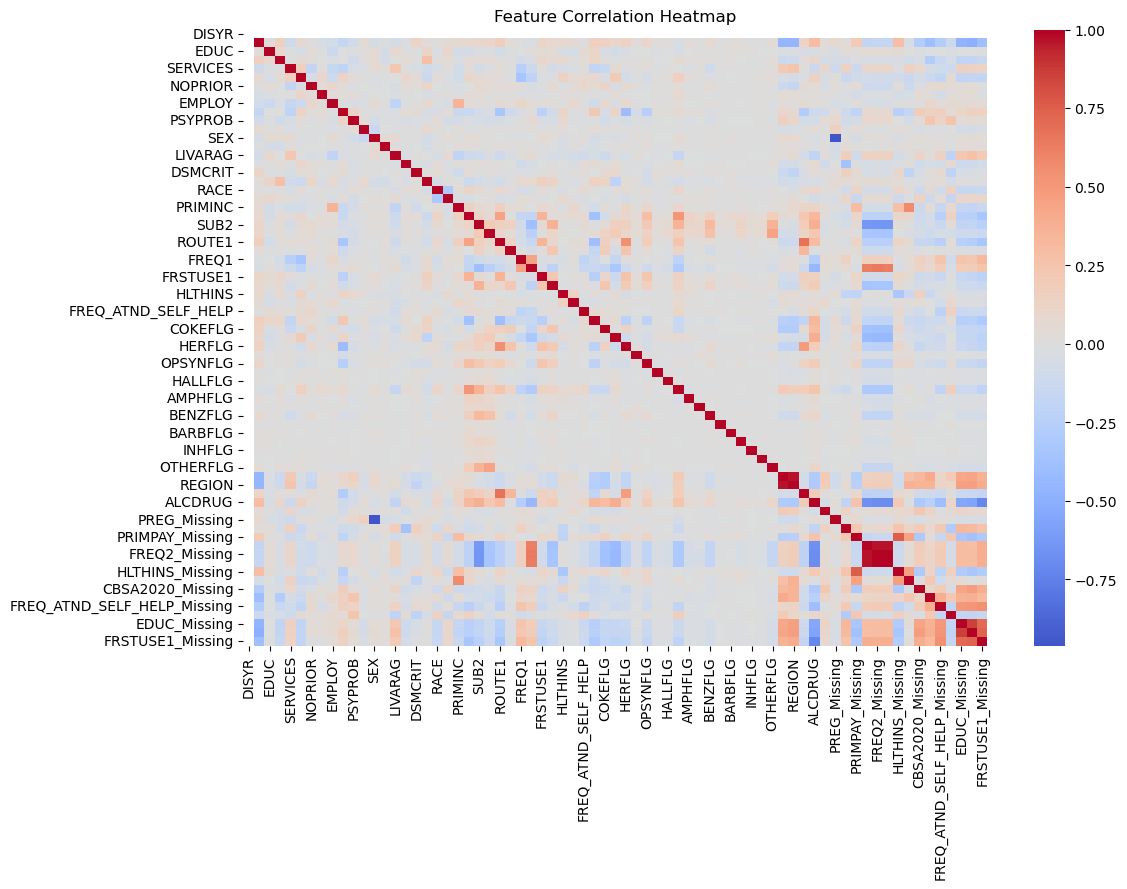

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(
    X_imputed.corr(),
    cmap='coolwarm',
    center=0
)
plt.title("Feature Correlation Heatmap")
plt.show()

## Final Summary 


This project analyzed 1.47 million behavioral health treatment discharge records to identify factors associated with successful treatment completion.

Following extensive data quality assessment, statistical testing, feature engineering, and predictive modeling, Random Forest and XGBoost models achieved strong predictive performance with ROC-AUC values of approximately 0.88.

Exploratory analysis identified several significant factors associated with treatment completion, including employment status, co-occurring mental health disorders, health insurance coverage, treatment access delays, and living arrangement status.

Feature importance analysis revealed that treatment service type, geographic location, substance use characteristics, and missing intake information were among the strongest predictors of treatment completion outcomes. These findings suggest that treatment retention is influenced by a combination of clinical complexity, socioeconomic stability, healthcare access, treatment delivery characteristics, and regional differences in care systems.

The results demonstrate that treatment completion can be predicted with high accuracy using information available at admission, enabling behavioral health organizations to identify high-risk patients and implement targeted retention interventions before treatment disengagement occurs.
